# Tareas de visión por computador

La tarea que queremos resolver decide cómo es una anotación y, por lo tanto,
qué debe devolver un `Dataset`. El modelo cambia, pero el patrón de carga es
siempre el mismo que usamos para la detección de carros: una subclase de
`Dataset` que lee el archivo de anotaciones, envuelve el objetivo en el tipo de
`tv_tensors` correcto dentro de `__getitem__` y deja que el pipeline de
`transforms.v2` mueva la imagen y el objetivo juntos.

| Tarea | Anotación | Tipo del objetivo | Agrupación en lotes |
|---|---|---|---|
| Clasificación | una clase por imagen | `int` | collate por defecto |
| Detección de objetos | una caja por objeto | `tv_tensors.BoundingBoxes` | collate propio |
| Segmentación semántica | una clase por píxel | `tv_tensors.Mask` `(H, W)` | collate por defecto |
| Segmentación de instancias | una máscara por objeto | `tv_tensors.Mask` `(K, H, W)` | collate propio |
| Estimación de pose | coordenadas de las articulaciones | `tv_tensors.KeyPoints` | collate propio |

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import tv_tensors
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.ops import masks_to_boxes

from utils import COCO_CLASSES, COCO_KEYPOINT_NAMES, COCO_SKELETON

DATA_ROOT = './data'
torch.manual_seed(42)

Dos funciones auxiliares que comparten todas las visualizaciones de abajo: las
imágenes llegan como tensores `CHW` de tipo float en `[0, 1]`, y las cajas
siempre se dibujan a partir de sus esquinas en formato `XYXY`.

In [2]:
def to_numpy_image(image):
    """Tensor CHW float en [0, 1] -> arreglo HWC que imshow entiende."""
    if isinstance(image, torch.Tensor):
        return image.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)
    return np.asarray(image)


def draw_boxes(ax, boxes, labels=None, color='red'):
    """Dibuja cajas XYXY sobre un eje existente, con una etiqueta opcional."""
    for i, (xmin, ymin, xmax, ymax) in enumerate(torch.as_tensor(boxes).tolist()):
        ax.add_patch(patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none'
        ))
        if labels is not None:
            ax.text(xmin, ymin - 4, labels[i], color='white', fontsize=8,
                    bbox=dict(facecolor=color, edgecolor='none', pad=1))

## 1. Clasificación de imágenes

La anotación más simple: una clase para toda la imagen. Aquí la etiqueta es el
nombre de la carpeta que contiene la imagen, así que el archivo de anotaciones
*es* la estructura de directorios. Los objetivos son enteros, de modo que la
función de collate por defecto ya los apila en un tensor `(B,)`.

In [3]:
class Scene_Dataset(Dataset):
    def __init__(self, img_dir, transform=None, target_transform=None):
        # Una clase por subcarpeta, ordenadas para que los índices de clase sean estables
        self.classes = sorted(entry.name for entry in os.scandir(img_dir) if entry.is_dir())
        class_to_idx = {name: i for i, name in enumerate(self.classes)}
        self.samples = [
            (path, class_to_idx[name])
            for name in self.classes
            for path in sorted(glob.glob(os.path.join(img_dir, name, '*.jpg')))
        ]
        self.img_dir = img_dir
        # Redimensionar para poder apilar en un lote imágenes de distintos tamaños
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Resize((128, 128)),
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        if self.target_transform:
            label = self.target_transform(label)
        return image, label


scene_dataset = Scene_Dataset(img_dir='./data/natural_06/seg_train/seg_train')
print(f"{len(scene_dataset)} imágenes, {len(scene_dataset.classes)} clases: {scene_dataset.classes}")

14034 imágenes, 6 clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
total_size = len(scene_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

scene_train_dataset, scene_val_dataset, scene_test_dataset = random_split(
    scene_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
scene_train_dataloader = DataLoader(scene_train_dataset, batch_size=16, shuffle=True)

samples, labels = next(iter(scene_train_dataloader))
print("Tamaño de las muestras:", samples.shape, "Tamaño de las etiquetas:", labels.shape)

Tamaño de las muestras: torch.Size([16, 3, 128, 128]) Tamaño de las etiquetas: torch.Size([16])


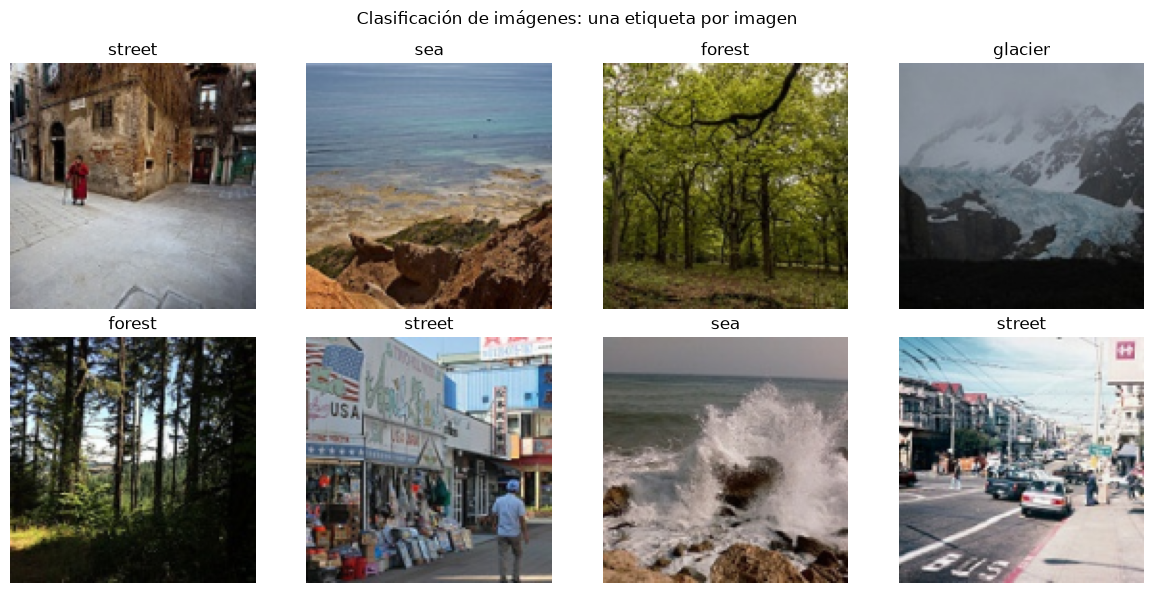

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.ravel(), samples, labels):
    ax.imshow(to_numpy_image(image))
    ax.set_title(scene_dataset.classes[label.item()])
    ax.axis('off')
fig.suptitle("Clasificación de imágenes: una etiqueta por imagen")
plt.tight_layout()
plt.show()

## 2. Detección de objetos

Ahora la anotación es una lista de cajas, y el número de cajas cambia de una
imagen a otra. `tv_tensors.BoundingBoxes` guarda el formato de las coordenadas
y el tamaño del lienzo, que es lo que permite que una transformación
geométrica mueva las cajas junto con la imagen. Como los objetivos tienen
longitudes distintas no se pueden apilar, así que el `DataLoader` necesita un
`collate_fn` propio.

In [6]:
class Car_Dataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        img_labels = pd.read_csv(annotations_file)
        # Una imagen puede contener varios carros, así que guardamos una entrada por
        # imagen con todas sus cajas apiladas en un arreglo (N, 4)
        self.samples = [
            (name, boxes[["xmin", "ymin", "xmax", "ymax"]].to_numpy(dtype=np.float32))
            for name, boxes in img_labels.groupby("image", sort=True)
        ]
        self.img_dir = img_dir
        # Sin transformación, igual devolvemos un tensor float en [0, 1]
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True)
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, boxes = self.samples[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Forma (N, 4), donde N es el número de carros anotados en esta imagen
        bounding_boxes = tv_tensors.BoundingBoxes(
            torch.tensor(boxes, dtype=torch.float32),
            format="XYXY",
            canvas_size=(image.height, image.width)
        )

        image, bounding_boxes = self.transform(image, bounding_boxes)

        if self.target_transform:
            bounding_boxes = self.target_transform(bounding_boxes)
        return image, bounding_boxes


car_dataset = Car_Dataset(
    annotations_file='./data/car_detection/bounding_boxes.csv',
    img_dir='./data/car_detection/images'
)
print(f"{len(car_dataset)} fotogramas anotados")

355 fotogramas anotados


In [7]:
def collate_detection(batch):
    # Las anotaciones tienen un número variable de cajas, así que no se pueden apilar
    # en un solo tensor: los dejamos como una lista de B tensores de tamaño (N_i, 4)
    images = torch.stack([item[0] for item in batch]) #(B, C, H, W)
    targets = [item[1] for item in batch] #Lista de B tensores de tamaño (N_i, 4)
    return images, targets


car_train_dataloader = DataLoader(car_dataset, batch_size=16, shuffle=True,
                                  collate_fn=collate_detection)

samples, bounding_boxes = next(iter(car_train_dataloader))
print("Tamaño de las muestras:", samples.shape)
print("Cajas por imagen en el lote:", [b.shape[0] for b in bounding_boxes])

Tamaño de las muestras: torch.Size([16, 3, 380, 676])
Cajas por imagen en el lote: [1, 2, 2, 1, 1, 1, 3, 5, 3, 3, 1, 2, 1, 2, 1, 1]


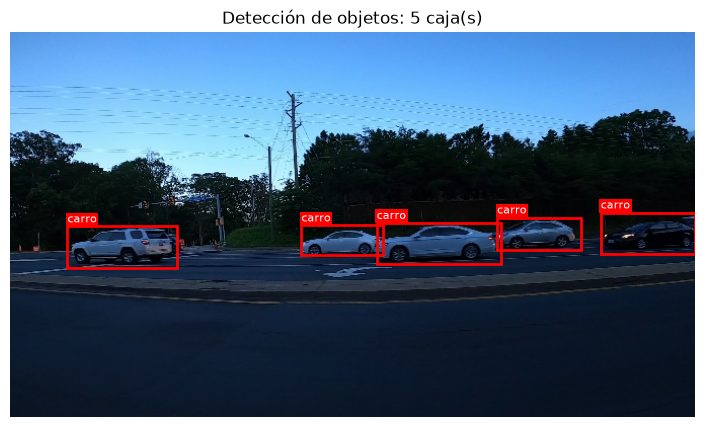

In [8]:
# Mostramos la imagen del lote con el mayor número de carros
idx = max(range(len(bounding_boxes)), key=lambda i: len(bounding_boxes[i]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(to_numpy_image(samples[idx]))
draw_boxes(ax, bounding_boxes[idx], labels=["carro"] * len(bounding_boxes[idx]))
ax.set_title(f"Detección de objetos: {len(bounding_boxes[idx])} caja(s)")
ax.axis('off')
plt.show()

## 3. Segmentación semántica

Una clase por *píxel*: el objetivo tiene el tamaño espacial de la imagen y
guarda un índice de clase en cada posición (aquí 0 es el fondo). Las muestras
de COCO traen las formas como polígonos normalizados, así que `__getitem__` las
rasteriza en una máscara. Envolverla como `tv_tensors.Mask` hace que las
transformaciones la redimensionen con interpolación por vecino más cercano, lo
que conserva intactos los índices de clase.

Note que la segmentación semántica no separa objetos: dos carros que se tocan
terminan como una sola mancha de la clase `car`.

In [9]:
def read_yolo_polygons(label_path):
    """Etiqueta de segmentación YOLO -> lista de (clase, polígono normalizado (P, 2))."""
    polygons = []
    with open(label_path) as f:
        for line in f:
            values = line.split()
            if not values:
                continue
            polygon = np.asarray(values[1:], dtype=np.float32).reshape(-1, 2)
            polygons.append((int(values[0]), polygon))
    return polygons


def rasterize_polygon(polygon, width, height, fill):
    """Rellena un polígono normalizado dentro de un arreglo (H, W) de tipo uint8."""
    canvas = Image.new("L", (width, height), 0)
    points = [(x * width, y * height) for x, y in polygon]
    ImageDraw.Draw(canvas).polygon(points, fill=fill)
    return np.asarray(canvas)


class Coco_Semantic_Dataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None, target_transform=None):
        self.samples = [
            (path, os.path.join(label_dir, os.path.basename(path).replace('.jpg', '.txt')))
            for path in sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        ]
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Resize((480, 480)),  # tamaño fijo para poder agrupar las máscaras
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        # Pintamos todos los polígonos sobre un mismo lienzo: valor del píxel =
        # índice de clase + 1, para que el 0 conserve el significado de "fondo"
        mask = np.zeros((image.height, image.width), dtype=np.uint8)
        for class_id, polygon in read_yolo_polygons(label_path):
            shape = rasterize_polygon(polygon, image.width, image.height, fill=class_id + 1)
            mask = np.where(shape > 0, shape, mask)

        segmentation_mask = tv_tensors.Mask(torch.from_numpy(mask))

        image, segmentation_mask = self.transform(image, segmentation_mask)

        if self.target_transform:
            segmentation_mask = self.target_transform(segmentation_mask)
        return image, segmentation_mask


semantic_dataset = Coco_Semantic_Dataset(
    img_dir='./data/coco8-seg/images/train',
    label_dir='./data/coco8-seg/labels/train'
)

image, segmentation_mask = semantic_dataset[0]
print("Imagen:", image.shape, image.dtype)
print("Máscara:", segmentation_mask.shape, segmentation_mask.dtype)
print("Clases presentes en la máscara:",
      [COCO_CLASSES[i - 1] for i in segmentation_mask.unique().tolist() if i > 0])

Imagen: torch.Size([3, 480, 480]) torch.float32
Máscara: torch.Size([480, 480]) torch.uint8
Clases presentes en la máscara: ['bowl', 'orange', 'broccoli']


In [10]:
# Las máscaras comparten el tamaño espacial de las imágenes, así que sirve el collate por defecto
semantic_dataloader = DataLoader(semantic_dataset, batch_size=4, shuffle=False)
samples, masks = next(iter(semantic_dataloader))
print("Tamaño de las muestras:", samples.shape, "Tamaño de las máscaras:", masks.shape)

Tamaño de las muestras: torch.Size([4, 3, 480, 480]) Tamaño de las máscaras: torch.Size([4, 480, 480])


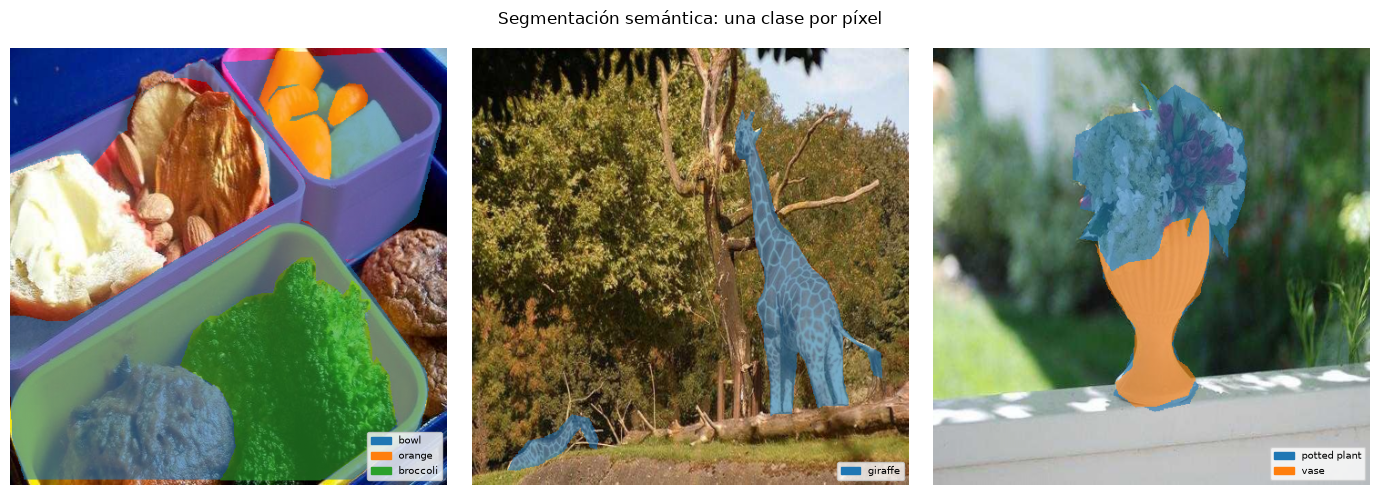

In [11]:
def overlay_mask(ax, mask, alpha=0.6):
    """Pinta cada índice de clase con su propio color y devuelve las clases dibujadas."""
    mask = torch.as_tensor(mask).cpu().numpy()
    colors = plt.get_cmap('tab10')
    class_ids = [i for i in np.unique(mask) if i > 0]
    overlay = np.zeros(mask.shape + (4,))
    for i, class_id in enumerate(class_ids):
        overlay[mask == class_id] = colors(i % 10)
    overlay[..., 3] *= alpha
    ax.imshow(overlay)
    return [patches.Patch(color=colors(i % 10), label=COCO_CLASSES[class_id - 1])
            for i, class_id in enumerate(class_ids)]


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, image, mask in zip(axes, samples, masks):
    ax.imshow(to_numpy_image(image))
    handles = overlay_mask(ax, mask)
    ax.legend(handles=handles, loc='lower right', fontsize=7)
    ax.axis('off')
fig.suptitle("Segmentación semántica: una clase por píxel")
plt.tight_layout()
plt.show()

## 4. Segmentación de instancias

La detección y la segmentación semántica combinadas: cada objeto recibe su
propia máscara binaria, así que dos objetos de la misma clase que se tocan
siguen separados. El objetivo es un diccionario, que es el formato que esperan
los modelos de detección de torchvision, y las cajas se derivan de las máscaras
con `masks_to_boxes` para que siempre sean consistentes. Las transformaciones
`v2` recorren el diccionario y actualizan máscaras y cajas al mismo tiempo.

In [12]:
class Coco_Instance_Dataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None, target_transform=None):
        self.samples = [
            (path, os.path.join(label_dir, os.path.basename(path).replace('.jpg', '.txt')))
            for path in sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        ]
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Resize((480, 480)),
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        # Una máscara binaria por objeto anotado -> (K, H, W)
        annotations = read_yolo_polygons(label_path)
        instance_masks = np.stack([
            rasterize_polygon(polygon, image.width, image.height, fill=1)
            for _, polygon in annotations
        ])
        labels = torch.tensor([class_id for class_id, _ in annotations], dtype=torch.int64)

        masks = tv_tensors.Mask(torch.from_numpy(instance_masks))
        # La caja más ajustada a cada máscara, para que cajas y máscaras no puedan discrepar
        boxes = tv_tensors.BoundingBoxes(
            masks_to_boxes(masks),
            format="XYXY",
            canvas_size=(image.height, image.width)
        )

        target = {"masks": masks, "boxes": boxes, "labels": labels}
        image, target = self.transform(image, target)

        if self.target_transform:
            target = self.target_transform(target)
        return image, target


instance_dataset = Coco_Instance_Dataset(
    img_dir='./data/coco8-seg/images/val',
    label_dir='./data/coco8-seg/labels/val'
)

image, target = instance_dataset[2]
print("Imagen:", image.shape)
print("Máscaras:", target["masks"].shape, "Cajas:", tuple(target["boxes"].shape))
print("Etiquetas:", [COCO_CLASSES[i] for i in target["labels"].tolist()])

Imagen: torch.Size([3, 480, 480])
Máscaras: torch.Size([9, 480, 480]) Cajas: (9, 4)
Etiquetas: ['horse', 'horse', 'person', 'person', 'person', 'potted plant', 'person', 'person', 'person']


In [13]:
def collate_instances(batch):
    # La misma idea de collate_detection: el número de objetos varía, así que los
    # objetivos se quedan en una lista de diccionarios
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    return images, targets


instance_dataloader = DataLoader(instance_dataset, batch_size=4, shuffle=False,
                                 collate_fn=collate_instances)
samples, targets = next(iter(instance_dataloader))
print("Tamaño de las muestras:", samples.shape)
print("Objetos por imagen:", [len(t["labels"]) for t in targets])

Tamaño de las muestras: torch.Size([4, 3, 480, 480])
Objetos por imagen: [2, 1, 9, 5]


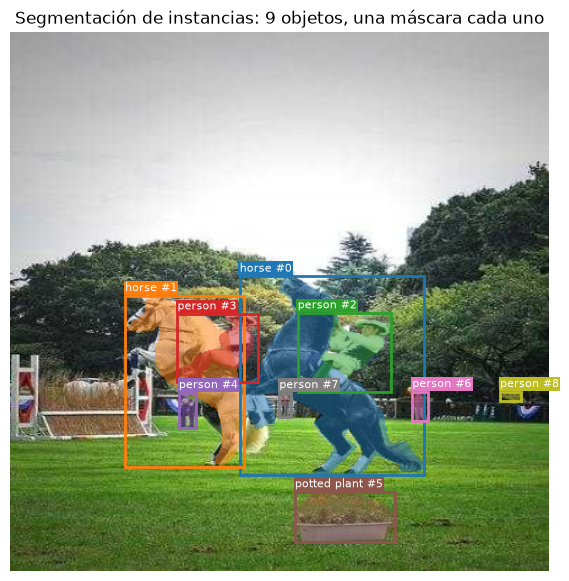

In [14]:
idx = max(range(len(targets)), key=lambda i: len(targets[i]["labels"]))
image, target = samples[idx], targets[idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(to_numpy_image(image))
colors = plt.get_cmap('tab10')
for i, (mask, box, label) in enumerate(zip(target["masks"], target["boxes"], target["labels"])):
    color = colors(i % 10)
    overlay = np.zeros(mask.shape + (4,))
    overlay[torch.as_tensor(mask).cpu().numpy() > 0] = color
    overlay[..., 3] *= 0.5
    ax.imshow(overlay)
    draw_boxes(ax, box.reshape(1, 4), labels=[f"{COCO_CLASSES[label]} #{i}"], color=color)
ax.set_title(f"Segmentación de instancias: {len(target['labels'])} objetos, una máscara cada uno")
ax.axis('off')
plt.show()

## 5. Estimación de pose (puntos clave)

La anotación es un conjunto de puntos en lugar de una región: COCO marca 17
articulaciones del cuerpo por persona, cada una con una bandera de visibilidad
(0 = sin anotar, 1 = anotada pero ocluida, 2 = visible). `tv_tensors.KeyPoints`
guarda las coordenadas `(N, 17, 2)` y permite que las transformaciones las
muevan; las banderas de visibilidad son un tensor común porque no dependen de
la geometría.

In [15]:
class Coco_Pose_Dataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None, target_transform=None):
        self.samples = [
            (path, os.path.join(label_dir, os.path.basename(path).replace('.jpg', '.txt')))
            for path in sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        ]
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Resize((480, 480)),
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        width, height = image.width, image.height

        # Cada fila es: clase, cx, cy, w, h, y luego 17 tripletas (x, y, visibilidad),
        # todas normalizadas por el tamaño de la imagen
        rows = np.loadtxt(label_path, dtype=np.float32, ndmin=2)
        labels = torch.from_numpy(rows[:, 0]).to(torch.int64)

        centers = rows[:, 1:5] * np.array([width, height, width, height], dtype=np.float32)
        corners = np.stack([
            centers[:, 0] - centers[:, 2] / 2, centers[:, 1] - centers[:, 3] / 2,
            centers[:, 0] + centers[:, 2] / 2, centers[:, 1] + centers[:, 3] / 2,
        ], axis=1)

        joints = rows[:, 5:].reshape(len(rows), -1, 3)
        coordinates = joints[..., :2] * np.array([width, height], dtype=np.float32)
        visibility = torch.from_numpy(joints[..., 2]).to(torch.uint8)

        target = {
            "keypoints": tv_tensors.KeyPoints(
                torch.from_numpy(coordinates), canvas_size=(height, width)
            ),
            "boxes": tv_tensors.BoundingBoxes(
                torch.from_numpy(corners), format="XYXY", canvas_size=(height, width)
            ),
            "visibility": visibility,
            "labels": labels,
        }
        image, target = self.transform(image, target)

        if self.target_transform:
            target = self.target_transform(target)
        return image, target


pose_dataset = Coco_Pose_Dataset(
    img_dir='./data/coco8-pose/images/val',
    label_dir='./data/coco8-pose/labels/val'
)

image, target = pose_dataset[0]
print("Imagen:", image.shape)
print("Puntos clave:", tuple(target["keypoints"].shape), "(personas, articulaciones, xy)")
print("Articulaciones visibles de la persona 0:",
      [COCO_KEYPOINT_NAMES[i] for i, v in enumerate(target["visibility"][0].tolist()) if v > 0])

Imagen: torch.Size([3, 480, 480])
Puntos clave: (8, 17, 2) (personas, articulaciones, xy)
Articulaciones visibles de la persona 0: ['nose', 'left_eye', 'right_eye', 'left_ear', 'left_shoulder', 'right_shoulder', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip']


In [16]:
pose_dataloader = DataLoader(pose_dataset, batch_size=4, shuffle=False,
                             collate_fn=collate_instances)
samples, targets = next(iter(pose_dataloader))
print("Personas por imagen:", [len(t["labels"]) for t in targets])

Personas por imagen: [8, 3, 2, 1]


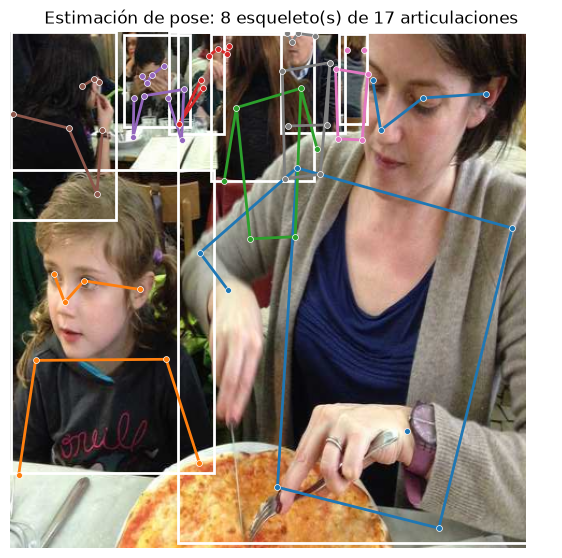

In [17]:
def draw_skeleton(ax, keypoints, visibility):
    """Une las articulaciones anotadas de cada persona siguiendo COCO_SKELETON."""
    keypoints = torch.as_tensor(keypoints).cpu().numpy()
    visibility = torch.as_tensor(visibility).cpu().numpy()
    colors = plt.get_cmap('tab10')
    for person, (person_joints, person_visibility) in enumerate(zip(keypoints, visibility)):
        color = colors(person % 10)
        for start, end in COCO_SKELETON:
            if person_visibility[start] > 0 and person_visibility[end] > 0:
                ax.plot(*zip(person_joints[start], person_joints[end]),
                        color=color, linewidth=2)
        annotated = person_visibility > 0
        ax.scatter(person_joints[annotated, 0], person_joints[annotated, 1],
                   s=18, color=color, edgecolors='white', linewidths=0.5, zorder=3)


idx = max(range(len(targets)), key=lambda i: len(targets[i]["labels"]))
image, target = samples[idx], targets[idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(to_numpy_image(image))
draw_boxes(ax, target["boxes"], color='white')
draw_skeleton(ax, target["keypoints"], target["visibility"])
ax.set_title(f"Estimación de pose: {len(target['labels'])} esqueleto(s) de 17 articulaciones")
ax.axis('off')
plt.show()

# Una misma aumentación, todos los tipos de anotación

Aquí se ve la razón para envolver los objetivos en `tv_tensors`: el mismo
pipeline de `transforms.v2` aplicado a cajas, máscaras y puntos clave los
actualiza a todos de forma consistente, y `SanitizeBoundingBoxes` descarta los
objetos que una rotación sacó fuera de la imagen.

In [18]:
geometry = [
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Resize((480, 480)),
    transforms.RandomRotation(degrees=20),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
]

augmentation = transforms.Compose(geometry)
# SanitizeBoundingBoxes falla si la muestra no tiene cajas, así que solo entra en
# el pipeline de los datasets cuyo objetivo realmente las contiene
box_augmentation = transforms.Compose(geometry + [transforms.SanitizeBoundingBoxes(labels_getter=None)])

car_aug_dataset = Car_Dataset(
    annotations_file='./data/car_detection/bounding_boxes.csv',
    img_dir='./data/car_detection/images',
    transform=box_augmentation
)
semantic_aug_dataset = Coco_Semantic_Dataset(
    img_dir='./data/coco8-seg/images/train',
    label_dir='./data/coco8-seg/labels/train',
    transform=augmentation
)
pose_aug_dataset = Coco_Pose_Dataset(
    img_dir='./data/coco8-pose/images/val',
    label_dir='./data/coco8-pose/labels/val',
    transform=augmentation
)

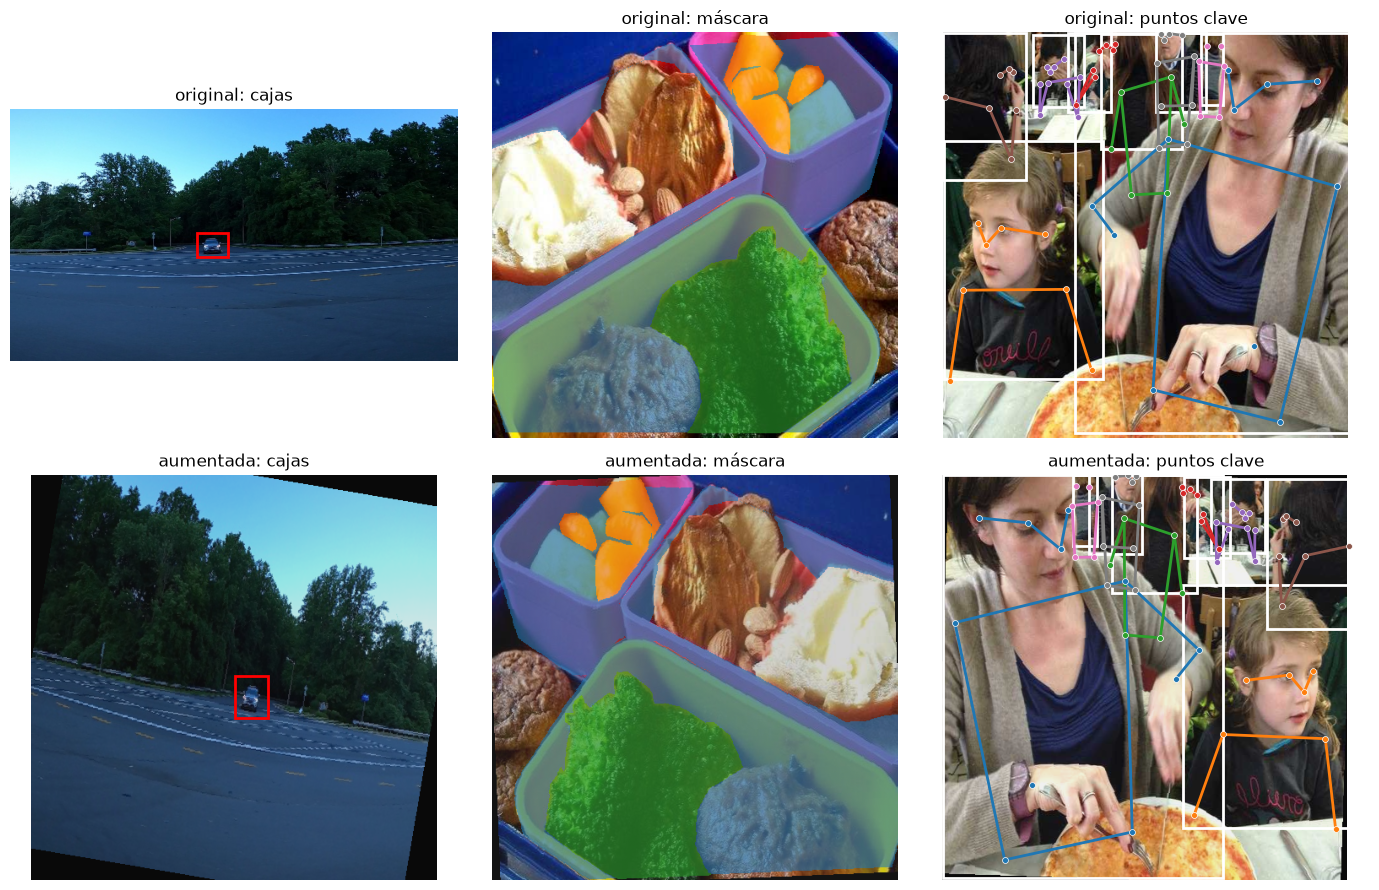

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for column, (title, dataset, idx) in enumerate([
    ("cajas", (car_dataset, car_aug_dataset), 0),
    ("máscara", (semantic_dataset, semantic_aug_dataset), 0),
    ("puntos clave", (pose_dataset, pose_aug_dataset), 0),
]):
    for row, source in enumerate(dataset):
        ax = axes[row, column]
        image, target = source[idx]
        ax.imshow(to_numpy_image(image))
        if title == "cajas":
            draw_boxes(ax, target)
        elif title == "máscara":
            overlay_mask(ax, target)
        else:
            draw_boxes(ax, target["boxes"], color='white')
            draw_skeleton(ax, target["keypoints"], target["visibility"])
        ax.set_title(f"{'original' if row == 0 else 'aumentada'}: {title}")
        ax.axis('off')

plt.tight_layout()
plt.show()

## Qué cambia entre tareas

El código de carga casi no se mueve: leer el archivo de anotaciones en
`__init__`, construir el objetivo en `__getitem__`, envolverlo en el tipo de
`tv_tensors` que corresponde a la tarea y dejar que las transformaciones hagan
el resto. Lo que sí cambia es

- **la anotación**, que pasa de un solo entero a estructuras por píxel o por objeto
- **la función de collate**, necesaria en cuanto el número de objetos anotados
  varía entre muestras. Standard collate require coincidencia de dimensiones. 
- **la métrica**, que es otra discusión: exactitud para clasificación, mAP para
  detección, IoU / Dice para segmentación, OKS para pose.